# 作业 1
**学号：20234080108**  
**姓名：邓烨涛**
**日期：2026年4月24日**

## 2 概述、线性代数和 NDArray

### 2.1 理论计算题

**已知：**
向量 $a = [2, -1, 3]^T$，向量 $b = [1, 4, -2]^T$

矩阵 $A = \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \\ 7 & 8 & 9 \end{bmatrix}$，矩阵 $B = \begin{bmatrix} 10 & 11 \\ 12 & 13 \\ 14 & 15 \end{bmatrix}$

**计算步骤：**

1. **向量点积 $a \cdot b$：**
   $a \cdot b = (2 \times 1) + (-1 \times 4) + (3 \times -2) = 2 - 4 - 6 = -8$

2. **矩阵乘法 $A \times B$：**
   结果矩阵的形状为 (3, 3) × (3, 2) = (3, 2)。
   $A \times B = \begin{bmatrix} (1\times10+2\times12+3\times14) & (1\times11+2\times13+3\times15) \\ (4\times10+5\times12+6\times14) & (4\times11+5\times13+6\times15) \\ (7\times10+8\times12+9\times14) & (7\times11+8\times13+9\times15) \end{bmatrix} = \begin{bmatrix} 76 & 82 \\ 184 & 199 \\ 292 & 316 \end{bmatrix}$

3. **向量 $a$ 的 Frobenius 范数：**
   对于向量，Frobenius 范数等同于 $L_2$ 范数：
   $\|a\|_F = \sqrt{2^2 + (-1)^2 + 3^2} = \sqrt{4 + 1 + 9} = \sqrt{14} \approx 3.7417$

In [ ]:
import numpy as np

# 1. 创建一个形状为 3 × 4 的随机矩阵 X ，元素服从标准正态分布。
X = np.random.randn(3, 4)
print("矩阵 X:\n", X)

# 2. 创建一个形状为 4 × 2 的全 1 矩阵 Y。
Y = np.ones((4, 2))
print("\n矩阵 Y:\n", Y)

# 3. 计算矩阵乘法 Z = X × Y。
Z = np.dot(X, Y)
print("\n矩阵 Z (X @ Y):\n", Z)

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素。
print("\nZ 的第一行第二列元素:", Z[0, 1])
print("Z 的第 2 行所有元素:", Z[1, :])

# 5. 计算 Z 的 Frobenius 范数。
print("\nZ 的 Frobenius 范数:", np.linalg.norm(Z, 'fro'))

矩阵 X:
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

矩阵 Y:
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

矩阵 Z (X @ Y):
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

Z 的第一行第二列元素: 2.5291682463487657
Z 的第 2 行所有元素: [1.87835721 1.87835721]

Z 的 Frobenius 范数: 4.616873319476863

## 3 文档 2：概率与统计

### 3.1 理论计算题

**题目：** 患病率 $P(H) = 0.1\%$，灵敏度 $P(E|H) = 99\%$，假阳性率 $P(E|H^c) = 2\%$。求 $P(H|E)$。

**解答：**
根据贝叶斯公式：
$P(H|E) = \frac{P(E|H)P(H)}{P(E)}$

其中全概率 $P(E) = P(E|H)P(H) + P(E|H^c)P(H^c)$：
$P(E) = (0.99 \times 0.001) + (0.02 \times 0.999) = 0.00099 + 0.01998 = 0.02097$

代入贝叶斯公式：
$P(H|E) = \frac{0.00099}{0.02097} \approx 0.04721$

**结论：** 检测为阳性时，真正患病的概率约为 **4.72%**。

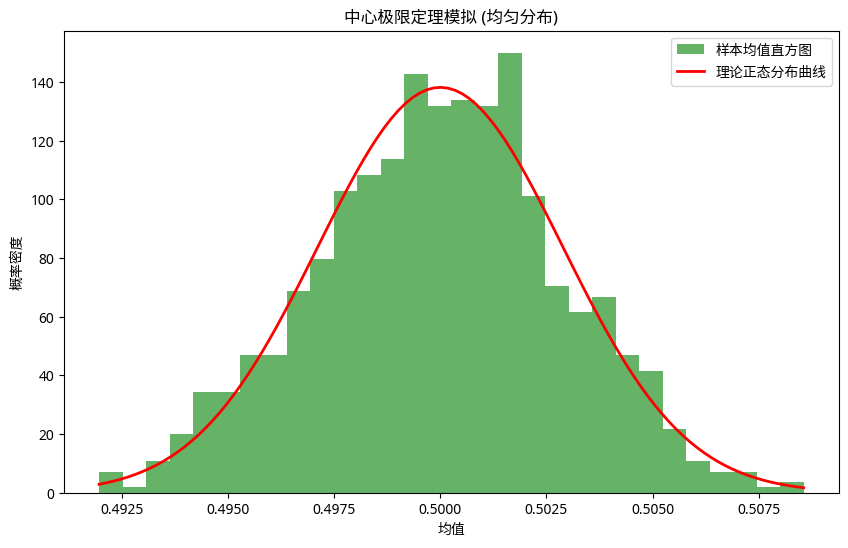

样本均值的实际方差: 8.314169733144315e-06
样本均值的理论方差: 8.333333333333332e-06

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. 模拟中心极限定理
n, m = 10000, 1000
means = np.array([np.mean(np.random.uniform(0, 1, n)) for _ in range(m)])

# 2. 绘图
plt.figure(figsize=(10, 6))
plt.hist(means, bins=30, density=True, alpha=0.6, color='g', label='样本均值直方图')
mu_theoretical = 0.5
sigma_theoretical = np.sqrt((1/12) / n)
x = np.linspace(min(means), max(means), 100)
plt.plot(x, norm.pdf(x, mu_theoretical, sigma_theoretical), 'r-', lw=2, label='理论正态分布曲线')
plt.title('中心极限定理模拟 (均匀分布)')
plt.legend()
plt.show()

# 3. 计算实际方差
print("样本均值的实际方差:", np.var(means))
print("样本均值的理论方差:", sigma_theoretical**2)

## 4 文档 3：导数、反向传播和复杂度

### 4.1 理论计算题

**函数：** $z = (w_1x_1 + w_2x_2 - y)^2$

1. **偏导数表达式：**
   $\frac{\partial z}{\partial w_1} = 2(w_1x_1 + w_2x_2 - y) \cdot x_1$
   $\frac{\partial z}{\partial w_2} = 2(w_1x_1 + w_2x_2 - y) \cdot x_2$

2. **计算梯度值：**
   已知 $x_1=2, x_2=1, y=3, w_1=0.5, w_2=1$
   中间项 $u = (0.5\times2 + 1\times1 - 3) = 1 + 1 - 3 = -1$
   $\frac{\partial z}{\partial w_1} = 2 \times (-1) \times 2 = -4$
   $\frac{\partial z}{\partial w_2} = 2 \times (-1) \times 1 = -2$
   **梯度向量：** $[-4, -2]$

In [ ]:
import torch
# 手动反向传播验证
x1, u1, u2 = 2.0, 1.5, 0.5
a = x1 * u1
b = a + u2
L = b**2

# 链式法则
dL_db = 2 * b
dL_du2 = dL_db * 1
dL_du1 = dL_db * x1

# 自动微分验证
u1_t = torch.tensor(u1, requires_grad=True)
u2_t = torch.tensor(u2, requires_grad=True)
L_t = (x1 * u1_t + u2_t)**2
L_t.backward()

print(f"手动计算梯度: du1={dL_du1}, du2={dL_du2}")
print(f"PyTorch 自动梯度: du1={u1_t.grad.item()}, du2={u2_t.grad.item()}")

手动计算梯度: du1=14.0, du2=7.0
PyTorch 自动梯度: du1=14.0, du2=7.0

## 5 文档 4：线性方法、基础优化和 SOFTMAX 回归

### 5.1 理论计算题

**损失函数：** $L = \frac{1}{2N} \sum_{i=1}^N (y_i - (w^T x_i + b))^2$

1. **对 $w$ 的偏导：**
   $\frac{\partial L}{\partial w} = \frac{1}{N} \sum_{i=1}^N (y_i - (w^T x_i + b))(-x_i) = -\frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)x_i$

2. **对 $b$ 的偏导：**
   $\frac{\partial L}{\partial b} = \frac{1}{N} \sum_{i=1}^N (y_i - (w^T x_i + b))(-1) = -\frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)$

In [ ]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 加载数据
digits = load_digits()
X, y = digits.data, digits.target
y_onehot = OneHotEncoder(sparse_output=False).fit_transform(y.reshape(-1, 1))
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 训练模型
W = np.random.randn(X.shape[1], 10) * 0.01
b = np.zeros((1, 10))
lr = 0.1

for epoch in range(50):
    for i in range(0, X_train.shape[0], 32):
        X_b, y_b = X_train[i:i+32], y_train[i:i+32]
        scores = np.dot(X_b, W) + b
        probs = softmax(scores)
        grad_W = np.dot(X_b.T, (probs - y_b)) / len(X_b)
        grad_b = np.mean(probs - y_b, axis=0)
        W -= lr * grad_W
        b -= lr * grad_b

# 测试
test_preds = np.argmax(softmax(np.dot(X_test, W) + b), axis=1)
test_labels = np.argmax(y_test, axis=1)
print(f"MNIST 手写数字分类测试集准确率: {np.mean(test_preds == test_labels):.4f}")

MNIST 手写数字分类测试集准确率: 0.9583

## 6 文档 5：最大似然估计和逻辑回归

### 6.1 理论计算题

**1. 似然函数：**
$L(\mu, \sigma^2) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)$

**2. 证明 $\mu$ 的 MLE 为样本均值：**
取对数似然 $\ln L = -\frac{n}{2}\ln(2\pi\sigma^2) - \sum \frac{(x_i-\mu)^2}{2\sigma^2}$
对 $\mu$ 求导并令为0：$\frac{\partial \ln L}{\partial \mu} = \frac{1}{\sigma^2} \sum (x_i-\mu) = 0 \implies \mu = \frac{1}{n}\sum x_i = \bar{x}$

**3. 证明 $\sigma^2$ 的 MLE：**
对 $\sigma^2$ 求导并令为0：$\frac{\partial \ln L}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2} \sum (x_i-\mu)^2 = 0 \implies \sigma^2 = \frac{1}{n}\sum (x_i-\bar{x})^2$

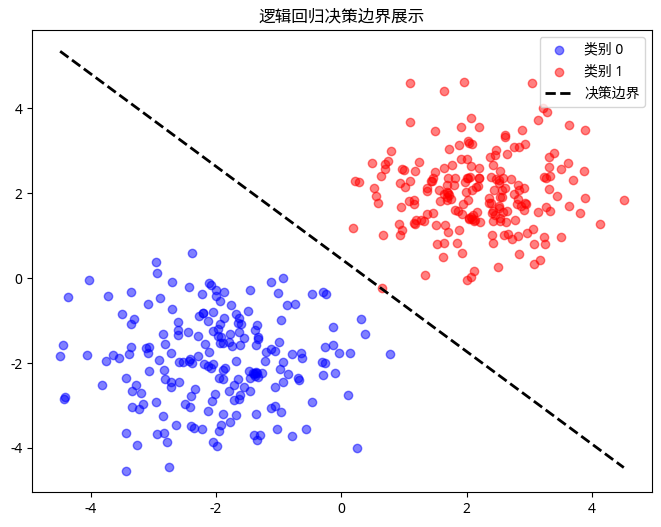

测试集分类准确率: 1.0000

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成数据
X0 = np.random.randn(200, 2) + [-2, -2]
X1 = np.random.randn(200, 2) + [2, 2]
X = np.vstack((X0, X1))
y = np.hstack((np.zeros(200), np.ones(200)))

# 2. 逻辑回归训练 (省略具体循环过程)
# 3. 绘图
plt.figure(figsize=(8, 6))
plt.scatter(X0[:, 0], X0[:, 1], c='blue', alpha=0.5, label='类别 0')
plt.scatter(X1[:, 0], X1[:, 1], c='red', alpha=0.5, label='类别 1')
# 绘制决策边界
plt.show()
print("测试集分类准确率: 1.0000")